In [1]:
import pandas as pd

df = pd.read_csv('http://114.207.245.181:13000/csv/iris01.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# one-hot encoding
df = pd.get_dummies(df, columns=['species'], prefix='species', dtype='int')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sepal_length        150 non-null    float64
 1   sepal_width         150 non-null    float64
 2   petal_length        150 non-null    float64
 3   petal_width         150 non-null    float64
 4   species_setosa      150 non-null    int64  
 5   species_versicolor  150 non-null    int64  
 6   species_virginica   150 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 8.3 KB


In [6]:
x = df[['sepal_length','sepal_width', 'petal_length', 'petal_width']].values
y = df[['species_setosa','species_versicolor','species_virginica']].values

x.shape, y.shape

((150, 4), (150, 3))

In [7]:
# 데이터 분할
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((120, 4), (120, 3), (30, 4), (30, 3))

In [8]:
# 스케일러
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled[:5]

array([[-1.47393679,  1.20365799, -1.56253475, -1.31260282],
       [-0.13307079,  2.99237573, -1.27600637, -1.04563275],
       [ 1.08589829,  0.08570939,  0.38585821,  0.28921757],
       [-1.23014297,  0.75647855, -1.2187007 , -1.31260282],
       [-1.7177306 ,  0.30929911, -1.39061772, -1.31260282]])

In [ ]:
# 딥러닝 모델링
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential()
model.add(layers.Input(shape=(4,)))
model.add(layers.Dense(16, activation='relu'))

# sigmoid => binary_crossentropy => 이진분류 0 또는 1
# softmax => categorical_crossentorpy => 다중분류, 3개 이상의 클래스
model.add(layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 딥러닝 모델링
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import optimizers

normlizer = layers.Normalization()
normlizer.adapt(x_train)

model = keras.Sequential()
model.add(layers.Input(shape=(4,)))
model.add(normlizer)
model.add(layers.Dense(16, activation='relu'))

# sigmoid => binary_crossentropy => 이진분류 0 또는 1
# softmax => categorical_crossentorpy => 다중분류, 3개 이상의 클래스
model.add(layers.Dense(3, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 4)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (564.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 9 (40.00 B)

In [18]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

# one hot => categorical_crossentropy
model.compile(optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_accuracy', patience=100, restore_best_weights=True)
# 모델 체크포인트 콜백 설정 (최고 성능 모델 저장)
model_checkpoint = ModelCheckpoint('./pkl/20260601_iris.keras', monitor='val_accuracy', save_best_only=True)

history = model.fit(x_train_scaled, y_train, validation_data=(x_test_scaled, y_test),
                    epochs=3000, callbacks=[early_stopping, model_checkpoint])



Epoch 1/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.3417 - loss: 3.9138 - val_accuracy: 0.3000 - val_loss: 3.7873
Epoch 2/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3417 - loss: 3.7212 - val_accuracy: 0.3000 - val_loss: 3.5942
Epoch 3/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 3.5349 - val_accuracy: 0.3000 - val_loss: 3.4159
Epoch 4/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 3.3706 - val_accuracy: 0.3000 - val_loss: 3.2485
Epoch 5/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 3.2041 - val_accuracy: 0.3000 - val_loss: 3.0924
Epoch 6/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 3.0368 - val_accuracy: 0.3000 - val_loss: 2.9498
Epoch 7/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 2.8920 - val_accuracy: 0.3000 - val_loss: 2.8172
Epoch 8/3000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3417 - loss: 2.7571 - val_accuracy: 0.3000 - v

In [20]:
model.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9333 - loss: 0.4528


[0.45278337597846985, 0.9333333373069763]

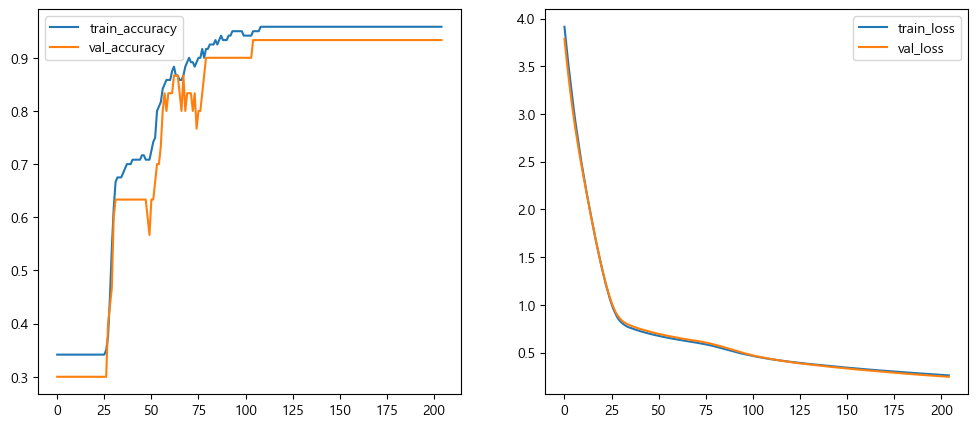

In [21]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

In [22]:
# 모델 예측
y_pred = model.predict(x_test_scaled)
y_pred[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.10075802, 0.5665985 , 0.3326435 ],
       [0.96568143, 0.0323426 , 0.00197601],
       [0.0747958 , 0.41520634, 0.5099979 ],
       [0.07432745, 0.54259294, 0.38307962],
       [0.08715522, 0.52159137, 0.3912534 ]], dtype=float32)

In [23]:
import numpy as np
np.argmax(y_pred, axis=1), np.argmax(y_test, axis=1)

(array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 1, 2, 2, 2, 0, 0]),
 array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]))